# Stage 1 - Step 3: Linear probe (the required baseline)

This is the one everyone in the class has to implement. The model is dead simple:

`s = W z + b`

where `z` is the frozen feature we cached in notebook 2, and `W, b` are the only
things we ever train. Trained with softmax cross-entropy, using the config the
assignment suggests (AdamW, lr 1e-3, weight decay 1e-4, batch size 64, up to 200
epochs, keep whichever epoch had the best validation accuracy).

What we're sweeping over, per the assignment:
- **3 (encoder, dataset) combinations**: ResNet-18/DTD, ResNet-18/Aircraft, DINOv2/Aircraft
- **3 training-set sizes**: 5-shot, 10-shot, full
- **3 seeds each**: for 5-shot/10-shot the seed controls *which* images get sampled
  into the subset (using the required seeds {0,1,2}); for the full setting there's no
  subsampling to vary, so the seed instead controls the classifier's random
  initialization, as the assignment specifies.

That's 3 x 3 x 3 = 27 total training runs. Because everything here trains on cached
feature vectors (not images), each run is fast - we're not touching the GPU-heavy
encoders again.

We also save the full loss curves for one representative run (10-shot, seed 0) per
combination, since the assignment wants us to show training/val curves for those.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_ROOT = '/content/drive/MyDrive/cvlab_stage1'
CACHE_ROOT = os.path.join(PROJECT_ROOT, 'features')
RESULTS_ROOT = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(RESULTS_ROOT, exist_ok=True)

print('reading cached features from:', CACHE_ROOT)
print('writing results to:', RESULTS_ROOT)

reading cached features from: /content/drive/MyDrive/cvlab_stage1/features
writing results to: /content/drive/MyDrive/cvlab_stage1/results


In [3]:
import torch
import torch.nn as nn
import numpy as np
import json
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


## Loading cached features

Just reading the `.pt` files notebook 2 produced - no encoder involved from here on.

In [4]:
def load_features(encoder, dataset, split):
    path = os.path.join(CACHE_ROOT, f'{encoder}_{dataset}_{split}.pt')
    d = torch.load(path)
    return d['features'], d['labels'], d['classes']

# quick check that everything we need is actually there
combos = [('resnet18', 'dtd'), ('resnet18', 'aircraft'), ('dinov2', 'aircraft')]
for encoder, dataset in combos:
    for split in ['train', 'val', 'test']:
        feats, labels, classes = load_features(encoder, dataset, split)
        print(f'{encoder:9s} {dataset:9s} {split:5s}: {feats.shape}, {len(classes)} classes')

resnet18  dtd       train: torch.Size([1880, 512]), 47 classes
resnet18  dtd       val  : torch.Size([1880, 512]), 47 classes
resnet18  dtd       test : torch.Size([1880, 512]), 47 classes
resnet18  aircraft  train: torch.Size([3334, 512]), 100 classes
resnet18  aircraft  val  : torch.Size([3333, 512]), 100 classes
resnet18  aircraft  test : torch.Size([3333, 512]), 100 classes
dinov2    aircraft  train: torch.Size([3334, 384]), 100 classes
dinov2    aircraft  val  : torch.Size([3333, 384]), 100 classes
dinov2    aircraft  test : torch.Size([3333, 384]), 100 classes


## K-shot subsampling

For 5-shot and 10-shot, we sample exactly K images per class from the cached full
training split, using a seeded random generator so the sampling is reproducible
(same seed = same images every time we re-run this).

We're sampling **without replacement** and forcing exactly K per class (balanced),
which is what the assignment means by "balanced subsets".

In [5]:
def make_kshot_subset(features, labels, k, seed):
    rng = np.random.RandomState(seed)
    labels_np = labels.numpy()
    classes = np.unique(labels_np)
    selected_idx = []
    for c in classes:
        idx_c = np.where(labels_np == c)[0]
        if len(idx_c) < k:
            raise ValueError(f'class {c} only has {len(idx_c)} images, need {k}')
        chosen = rng.choice(idx_c, size=k, replace=False)
        selected_idx.extend(chosen.tolist())
    selected_idx = np.array(selected_idx)
    return features[selected_idx], labels[selected_idx]

## The linear probe model + training loop

Nothing fancy - a single `nn.Linear` layer, trained with the suggested
hyperparameters. We evaluate on the validation set every epoch and keep a copy of
whichever epoch's weights got the best validation accuracy (that's the "checkpoint
selection" the assignment asks for) - at the end we load that best checkpoint back in
before computing the final test accuracy, so we're never reporting test performance
from an overfit late-stage checkpoint.

`track_curves=True` additionally records the per-epoch train/val loss so we can plot
it later - we only turn this on for the one representative run per combination.

In [6]:
def train_linear_probe(train_feats, train_labels, val_feats, val_labels, test_feats, test_labels,
                        num_classes, seed, max_epochs=200, lr=1e-3, weight_decay=1e-4,
                        batch_size=64, track_curves=False):
    torch.manual_seed(seed)

    feat_dim = train_feats.shape[1]
    model = nn.Linear(feat_dim, num_classes).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    train_feats_d = train_feats.to(device)
    train_labels_d = train_labels.to(device)
    val_feats_d = val_feats.to(device)
    val_labels_d = val_labels.to(device)
    test_feats_d = test_feats.to(device)
    test_labels_d = test_labels.to(device)

    train_ds = torch.utils.data.TensorDataset(train_feats_d, train_labels_d)
    gen = torch.Generator().manual_seed(seed)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=gen)

    best_val_acc = -1.0
    best_state = None
    train_loss_hist, val_loss_hist = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss, n = 0.0, 0
        for xb, yb in train_loader:
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * xb.size(0)
            n += xb.size(0)
        train_loss = epoch_loss / n

        model.eval()
        with torch.no_grad():
            val_logits = model(val_feats_d)
            val_loss = criterion(val_logits, val_labels_d).item()
            val_acc = (val_logits.argmax(1) == val_labels_d).float().mean().item()

        if track_curves:
            train_loss_hist.append(train_loss)
            val_loss_hist.append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(test_feats_d)
        test_acc = (test_logits.argmax(1) == test_labels_d).float().mean().item()

    result = {'test_acc': test_acc, 'best_val_acc': best_val_acc}
    if track_curves:
        result['train_loss_hist'] = train_loss_hist
        result['val_loss_hist'] = val_loss_hist
    return result

## Running the full sweep (27 runs)

This is the main event. For each of the 3 combinations, we load the cached features
once, then loop over K in {5, 10, full} x 3 seeds. We only track the full loss curve
for the 10-shot / seed 0 run of each combination - that's our "representative" run
for the required training-curve plot.

This should take somewhere between a couple minutes and maybe ten, depending on the
GPU - nothing here needs much compute since we're just training a single linear layer
on top of already-extracted features.

In [7]:
K_SETTINGS = [5, 10, 'full']
SEEDS = [0, 1, 2]

all_results = []
curve_data = {}  # representative 10-shot curves, keyed by 'encoder_dataset'

for encoder, dataset in combos:
    print(f'=== {encoder} / {dataset} ===')
    train_feats, train_labels, classes = load_features(encoder, dataset, 'train')
    val_feats, val_labels, _ = load_features(encoder, dataset, 'val')
    test_feats, test_labels, _ = load_features(encoder, dataset, 'test')
    num_classes = len(classes)

    for K in K_SETTINGS:
        for seed in SEEDS:
            if K == 'full':
                subset_feats, subset_labels = train_feats, train_labels
            else:
                subset_feats, subset_labels = make_kshot_subset(train_feats, train_labels, k=K, seed=seed)

            track = (K == 10 and seed == 0)
            result = train_linear_probe(
                subset_feats, subset_labels, val_feats, val_labels, test_feats, test_labels,
                num_classes=num_classes, seed=seed, track_curves=track
            )

            row = {
                'encoder': encoder, 'dataset': dataset, 'K': str(K), 'seed': seed,
                'n_train': len(subset_labels), 'best_val_acc': result['best_val_acc'],
                'test_acc': result['test_acc'],
            }
            all_results.append(row)
            print(f"  K={str(K):5s} seed={seed}  n_train={row['n_train']:5d}  "
                  f"val_acc={result['best_val_acc']:.4f}  test_acc={result['test_acc']:.4f}")

            if track:
                curve_data[f'{encoder}_{dataset}'] = {
                    'train_loss': result['train_loss_hist'],
                    'val_loss': result['val_loss_hist'],
                }

print()
print(f'Done. {len(all_results)} total runs (expected 27).')
assert len(all_results) == 27

=== resnet18 / dtd ===
  K=5     seed=0  n_train=  235  val_acc=0.4633  test_acc=0.4585
  K=5     seed=1  n_train=  235  val_acc=0.4436  test_acc=0.4277
  K=5     seed=2  n_train=  235  val_acc=0.4468  test_acc=0.4569
  K=10    seed=0  n_train=  470  val_acc=0.5138  test_acc=0.5165
  K=10    seed=1  n_train=  470  val_acc=0.5197  test_acc=0.5191
  K=10    seed=2  n_train=  470  val_acc=0.5229  test_acc=0.5340
  K=full  seed=0  n_train= 1880  val_acc=0.6101  test_acc=0.6298
  K=full  seed=1  n_train= 1880  val_acc=0.6069  test_acc=0.6261
  K=full  seed=2  n_train= 1880  val_acc=0.6074  test_acc=0.6293
=== resnet18 / aircraft ===
  K=5     seed=0  n_train=  500  val_acc=0.1920  test_acc=0.2010
  K=5     seed=1  n_train=  500  val_acc=0.2061  test_acc=0.2010
  K=5     seed=2  n_train=  500  val_acc=0.2076  test_acc=0.2025
  K=10    seed=0  n_train= 1000  val_acc=0.2634  test_acc=0.2706
  K=10    seed=1  n_train= 1000  val_acc=0.2709  test_acc=0.2844
  K=10    seed=2  n_train= 1000  val_ac

## Saving results

Results table goes to a CSV (easy to load in notebook 5 for the accuracy table and
accuracy-vs-K plot). The representative loss curves go to a separate JSON file.

In [8]:
results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_ROOT, 'linear_probe_results.csv'), index=False)

with open(os.path.join(RESULTS_ROOT, 'linear_probe_curves.json'), 'w') as f:
    json.dump(curve_data, f)

print('saved linear_probe_results.csv and linear_probe_curves.json to', RESULTS_ROOT)
results_df

saved linear_probe_results.csv and linear_probe_curves.json to /content/drive/MyDrive/cvlab_stage1/results


,encoder,dataset,K,seed,n_train,best_val_acc,test_acc
0,resnet18,dtd,5,0,235,0.463298,0.458511
1,resnet18,dtd,5,1,235,0.443617,0.427660
2,resnet18,dtd,5,2,235,0.446808,0.456915
3,resnet18,dtd,10,0,470,0.513830,0.516489
4,resnet18,dtd,10,1,470,0.519681,0.519149
5,resnet18,dtd,10,2,470,0.522872,0.534043
6,resnet18,dtd,full,0,1880,0.610106,0.629787
7,resnet18,dtd,full,1,1880,0.606915,0.626064
8,resnet18,dtd,full,2,1880,0.607447,0.629255
9,resnet18,aircraft,5,0,500,0.192019,0.201020


## Quick sanity look at the results

Before moving on, a couple of things worth eyeballing:
- Does accuracy generally go **up** as K increases (5 -> 10 -> full)? If not for a
  specific combo, that's worth a closer look (though small dips from 5 to 10 due to
  which specific images got sampled aren't necessarily alarming).
- Is the spread (std) across the 3 seeds reasonably small for the full setting, and
  larger for 5-shot? Higher variance with fewer shots is expected and is exactly the
  kind of thing the "error bars" in the required plot are meant to show.
- Quick look at the 10-shot representative curves - train loss should go down
  steadily; if val loss starts climbing while train loss keeps dropping, that's
  overfitting, which is fine to observe and discuss (the assignment explicitly asks
  whether "substantial overfitting occurs").

In [9]:
summary = results_df.groupby(['encoder', 'dataset', 'K'])['test_acc'].agg(['mean', 'std']).reset_index()
summary

,encoder,dataset,K,mean,std
0,dinov2,aircraft,10,0.519052,0.013320
1,dinov2,aircraft,5,0.383138,0.021803
2,dinov2,aircraft,full,0.670567,0.001082
3,resnet18,aircraft,10,0.275528,0.007722
4,resnet18,aircraft,5,0.201520,0.000866
5,resnet18,aircraft,full,0.369937,0.004059
6,resnet18,dtd,10,0.523227,0.009461
7,resnet18,dtd,5,0.447695,0.017370
8,resnet18,dtd,full,0.628369,0.002014


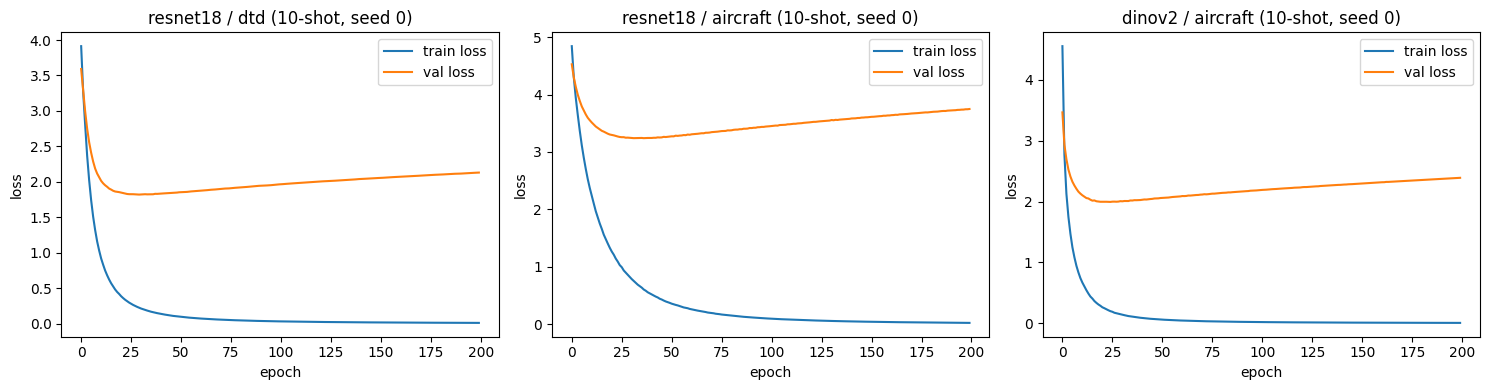

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (encoder, dataset) in zip(axes, combos):
    key = f'{encoder}_{dataset}'
    c = curve_data[key]
    ax.plot(c['train_loss'], label='train loss')
    ax.plot(c['val_loss'], label='val loss')
    ax.set_title(f'{encoder} / {dataset} (10-shot, seed 0)')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend()
plt.tight_layout()
plt.show()

## Before moving to notebook 4

Check that:
- [ ] `linear_probe_results.csv` has 27 rows in your Drive `results/` folder
- [ ] Accuracy roughly increases with more training data for each combination
- [ ] The 3 loss-curve plots above look like sane training (not flat, not exploding)

If something looks clearly broken (e.g. accuracy stuck near random chance for a
combo), stop here and let's debug it before building on top of it - same as we did
with the DINOv2/Aircraft assignment logic earlier.

Next up: **notebook 4**, the image-prototype baseline (Option A) - much shorter,
no training loop at all, just cosine similarity to class-mean vectors.